# 现代循环神经网络

## 门控循环单元(GRU)

### 门控隐状态

⻔控循环单元与普通的循环神经⽹络之间的关键区别在于：前者⽀持隐状态的⻔控。这意味着模型有专⻔的机制来确定应该何时更新隐状态，以及应该何时重置隐状态。这些机制是可学习的，并且能够解决了上⾯列出的问题。例如，如果第⼀个词元⾮常重要，模型将学会在第⼀次观测之后不更新隐状态。同样，模型也可以学会跳过不相关的临时观测。最后，模型还将学会在需要的时候重置隐状态。

#### 重置门和更新门

我们⾸先介绍重置⻔（resetgate）和更新⻔（updategate）。我们把它们设计成区间中的向量，这样我们就可以进⾏凸组合。重置⻔允许我们控制“可能还想记住”的过去状态的数量；更新⻔将允许我们控制新状态中有多少个是旧状态的副本。

图描述了⻔控循环单元中的重置⻔和更新⻔的输⼊，输⼊是由当前时间步的输⼊和前⼀时间步的隐状态给出。两个⻔的输出是由使⽤sigmoid激活函数的两个全连接层给出。

<div align="center">
    <img src="../img/在⻔控循环单元模型中计算重置⻔和更新⻔.png">
<div>

对于给定的时间步$t$，假设输⼊是⼀个⼩批量$X_t \in \mathbb{R}^{n \times d}$(样本个数，输⼊个数)，上⼀个时间步的隐状态是$H_{t-1} \in \mathbb{R}^{n \times h}$(隐藏单元个数)。那么，重置⻔$R_t \in \mathbb{R}^{n \times h}$和更新⻔$Z_t \in \mathbb{R}^{n \times h}$的计算如下所⽰：

$$
R_t = \sigma (X_t W_{xr} + H_{t - 1} W_{hr} + b_r)
$$
$$
Z_t = \sigma(X_t W_{xz} + H_{t - 1} W_{hz} + b_z)
$$

其中$W_{xr},W_{xz} \in \mathbb{R}^{d \times h}$和$W_{hr},W_{hz} \in \mathbb{R}^{h \times h}$是权重参数，$b_r,b_z \in \mathbb{R}^{1 \times h}$是偏置参数。请注意，在求和过程中会触发⼴播机制。我们使⽤sigmoid函数将输⼊值转换到区间(0, 1)。

#### 候选隐状态

在时间步$t$的候选隐状态$\tilde{H}_t \in \mathbb{R}^{n \times h}$:

$$
\tilde{H}_t = tanh(X_t W_{xh} + (R_t \odot H_{t - 1}) W_{hh} + b_h)
$$

其中$W_{xh} \in \mathbb{R}^{d \times h}$和$W_{hh} \in \mathbb{R}^{h \times h}$是权重参数，$b_h \in \mathbb{R}^{1 \times h}$是偏置项，符号$\odot$是Hadamard积（按元素乘积）运算符。在这⾥，我们使⽤tanh⾮线性激活函数来确保候选隐状态中的值保持在区间(-1, 1)中。

与普通循环神经网络相⽐，公式中的$R_t$和$H_{t - 1}$的元素相乘可以减少以往状态的影响。每当重置⻔$R_t$中的项接近$0$时，我们恢复⼀个如普通的循环神经⽹络。对于重置⻔$R_t$中所有接近$0$的项，候选隐状态是以$X_t$作为输⼊的多层感知机的结果。因此，任何预先存在的隐状态都会被重置为默认值。

<div align="center">
    <img src="../img/在⻔控循环单元模型中计算候选隐状态.png">
<div>

#### 隐状态

上述的计算结果只是候选隐状态，我们仍然需要结合更新⻔$Z_t$的效果。这⼀步确定新的隐状态$H_t \in \mathbb{R}^{n \times h}$在多⼤程度上来⾃旧的状态$H_{t-1}$和新的候选状态$\tilde{H}_t$。更新⻔$Z_t$仅需要在$H_{t-1}$和$\tilde{H}_t$之间进⾏按元素的凸组合就可以实现这个⽬标。这就得出了⻔控循环单元的最终更新公式：

$$
H_t = Z_t \odot H_{t-1} + (1 - Z_t) \odot \tilde{H}_t
$$

每当更新⻔$Z_t$接近$1$时，模型就倾向只保留旧状态。此时，来⾃$X_t$的信息基本上被忽略，从⽽有效地跳过了依赖链条中的时间步。相反，当$Z_t$接近$0$时，新的隐状态$H_t$就会接近候选隐状态$\tilde{H}_t$。这些设计可以帮助我们处理循环神经⽹络中的梯度消失问题，并更好地捕获时间步距离很⻓的序列的依赖关系。例如，如果整个⼦序列的所有时间步的更新⻔都接近于$1$，则⽆论序列的⻓度如何，在序列起始时间步的旧隐状态都将很容易保留并传递到序列结束。

<div align="center">
    <img src="../img/计算⻔控循环单元模型中的隐状态.png">
<div>

总之，⻔控循环单元具有以下两个显著特征：
- 重置⻔有助于捕获序列中的短期依赖关系；
- 更新⻔有助于捕获序列中的⻓期依赖关系。

#### GRU 门控小结

两个门都经 $\sigma$ 压到 $(0,1)$，按元素控制信息流，开多大由网络学习。

##### 1. 重置门 $R_t$（写候选时用）

$$
\tilde{H}_t = \tanh\bigl(X_t W_{xh} + (R_t \odot H_{t-1}) W_{hh} + b_h\bigr)
$$

- 控制：**算候选隐状态时，旧状态 $H_{t-1}$ 参与多少**
- $R\to 0$：几乎忽略过去，主要看当前输入（重置）
- $R\to 1$：过去充分参与，更像普通 RNN
- 作用偏向：**短期依赖**——哪些过去信息现在还相关

##### 2. 更新门 $Z_t$（写新状态时用）

$$
H_t = Z_t \odot H_{t-1} + (1 - Z_t) \odot \tilde{H}_t
$$

- 控制：**新隐状态里，旧记忆留多少、候选采纳多少**（凸组合）
- $Z\to 1$：基本保持 $H_{t-1}$，跳过本步更新
- $Z\to 0$：基本换成 $\tilde{H}_t$，写入新内容
- 作用偏向：**长期依赖**——重要信息可跨很多步原样传递

##### 一句话区分

| 门 | 一句话 |
|----|--------|
| 重置门 | 用 $R_t \odot H_{t-1}$ 控制：计算 $\tilde{H}_t$ 时，旧隐状态各维保留多少。偏短期 |
| 更新门 | 用 $Z_t$ 做凸组合：新的 $H_t$ 里，有多少来自旧的 $H_{t-1}$，有多少来自 $\tilde{H}_t$。偏长期 |

### 从零开始实现

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

#### 初始化模型参数

In [3]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three() # 更新门参数
    W_xr, W_hr, b_r = three() # 重置门参数
    W_xh, W_hh, b_h = three() # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params
    

#### 定义模型

In [4]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

In [5]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + (R * H @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, )

#### 训练与预测

困惑度 1.1, 19273.3 词元/秒 cuda:0
time traveller with a slight accession ofcheerfulness really thi
travelleryou can show black is white by argument said filby


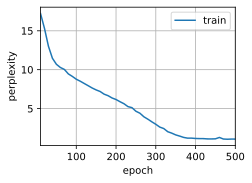

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params, 
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 简洁实现

困惑度 1.0, 242090.8 词元/秒 cuda:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


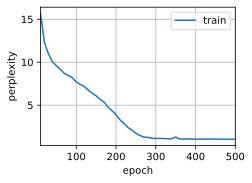

In [7]:
num_inputs = vocab_size
gru_layer = nn.GRU(num_inputs, num_hiddens)
model = d2l.RNNModel(gru_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 长短期记忆网络(LSTM)

### 门控记忆元

⻓短期记忆⽹络引⼊了记忆元（memorycell），或简称为单元（cell）。有些⽂献认为记忆元是隐状态的⼀种特殊类型，它们与隐状态具有相同的形状，其设计⽬的是⽤于记录附加的信息。为了控制记忆元，我们需要许多⻔。其中⼀个⻔⽤来从单元中输出条⽬，我们将其称为输出⻔（outputgate）。另外⼀个⻔⽤来决定何时将数据读⼊单元，我们将其称为输⼊⻔（inputgate）。我们还需要⼀种机制来重置单元的内容，由遗忘⻔（forgetgate）来管理，这种设计的动机与⻔控循环单元相同，能够通过专⽤机制决定什么时候记忆或忽略隐状态中的输⼊。

#### 输入门、忘记门和输出门

它们由三个具有sigmoid激活函数的全连接层处理，以计算输⼊⻔、遗忘⻔和输出⻔的值。因此，这三个⻔的值都在的范围内。

<div align="center">
    <img src="../img/输入门、遗忘门和输出门.png">
<div>

假设时间步 $t$ 的小批量输入为 $\mathbf{X}_t \in \mathbb{R}^{n \times d}$（样本数 $n$，输入个数 $d$），前一时步隐状态为 $\mathbf{H}_{t-1} \in \mathbb{R}^{n \times h}$（隐藏单元数 $h$）。相应地，时间步 $t$ 的输入门 $\mathbf{I}_t \in \mathbb{R}^{n \times h}$、遗忘门 $\mathbf{F}_t \in \mathbb{R}^{n \times h}$ 和输出门 $\mathbf{O}_t \in \mathbb{R}^{n \times h}$ 计算如下：

$$
\begin{aligned}
\mathbf{I}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xi} + \mathbf{H}_{t-1} \mathbf{W}_{hi} + \mathbf{b}_i), \\
\mathbf{F}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xf} + \mathbf{H}_{t-1} \mathbf{W}_{hf} + \mathbf{b}_f), \\
\mathbf{O}_t &= \sigma(\mathbf{X}_t \mathbf{W}_{xo} + \mathbf{H}_{t-1} \mathbf{W}_{ho} + \mathbf{b}_o),
\end{aligned}
$$

其中 $\mathbf{W}_{xi}, \mathbf{W}_{xf}, \mathbf{W}_{xo} \in \mathbb{R}^{d \times h}$ 和 $\mathbf{W}_{hi}, \mathbf{W}_{hf}, \mathbf{W}_{ho} \in \mathbb{R}^{h \times h}$ 是权重参数，$\mathbf{b}_i, \mathbf{b}_f, \mathbf{b}_o \in \mathbb{R}^{1 \times h}$ 是偏置参数。

#### 候选记忆元

由于还没有指定各种门的操作，所以先介绍候选记忆元（candidate memory cell）$\tilde{\mathbf{C}}_t \in \mathbb{R}^{n \times h}$。它的计算与上面描述的三个门的计算类似，但是使用tanh函数作为激活函数，函数的值范围为$(-1, 1)$。下面导出在时间步$t$处的方程：

$$
\tilde{\mathbf{C}}_t = \tanh(\mathbf{X}_t \mathbf{W}_{xc} + \mathbf{H}_{t-1} \mathbf{W}_{hc} + \mathbf{b}_c)
$$

其中$\mathbf{W}_{xc} \in \mathbb{R}^{d \times h}$和$\mathbf{W}_{hc} \in \mathbb{R}^{h \times h}$是权重参数，$\mathbf{b}_c \in \mathbb{R}^{1 \times h}$是偏置参数。

<div align="center">
    <img src="../img/LSTM候选记忆元.png">
<div>

#### 记忆元

在门控循环单元中，有一种机制来控制输入和遗忘（或跳过）。类似地，在长短期记忆网络中，也有两个门用于这样的目的：输入门 $\mathbf{I}_t$ 控制采用多少来自 $\tilde{\mathbf{C}}_t$ 的新数据，而遗忘门 $\mathbf{F}_t$ 控制保留多少过去的记忆元 $\mathbf{C}_{t-1} \in \mathbb{R}^{n \times h}$ 的内容。使用按元素乘法，得出：

$$
\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t.
$$

如果遗忘门始终为1且输入门始终为0，则过去的记忆元 $\mathbf{C}_{t-1}$ 将随时间被保存并传递到当前时间步。引入这种设计是为了缓解梯度消失问题，并更好地捕获序列中的长距离依赖关系。

#### 隐状态

最后，我们需要定义如何计算隐状态 $\mathbf{H}_t \in \mathbb{R}^{n \times h}$，这就是输出门发挥作用的地方。在长短期记忆网络中，它仅仅是记忆元的 $\tanh$ 的门控版本。这就确保了 $\mathbf{H}_t$ 的值始终在区间 $(-1, 1)$ 内：

$$
\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t).
$$

只要输出门接近 1，我们就能够有效地将所有记忆信息传递给预测部分，而对于输出门接近 0，我们只保留记忆元内的所有信息，而不需要更新隐状态。

<div align="center">
    <img src="../img/LSTM隐状态.png">
<div>

简单来说，用 $X_t$ 和 $H_{t-1}$ 算出候选记忆元 $\tilde{C}_t$；再用遗忘门保留旧记忆元、输入门写入候选得到 $C_t$；最后用输出门对 $\tanh(C_t)$ 门控，得到当前隐状态 $H_t$。

### 从零开始实现

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

#### 初始化模型参数

In [2]:
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device = device) * 0.01
    
    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xi, W_hi, b_i = three() # 输⼊⻔参数
    W_xf, W_hf, b_f = three() # 遗忘⻔参数
    W_xo, W_ho, b_o = three() # 输出⻔参数
    W_xc, W_hc, b_c = three() # 候选记忆元参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc,
                 b_c, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

#### 定义模型

在初始化函数中，⻓短期记忆⽹络的隐状态需要返回⼀个额外的记忆元，单元的值为0，形状为（批量⼤⼩，隐藏单元数）。因此，我们得到以下的状态初始化。

In [3]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

In [4]:
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xf, W_hf, b_f, W_xo, W_ho, b_o, W_xc, W_hc, b_c,
    W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = I * C_tilda + F * C
        H = O * torch.tanh(C)
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)

#### 训练和预测

困惑度 1.1, 15464.6 词元/秒 cuda:0
time travelleryou can show black is white by argument said filby
traveller for so it will be convenient to speak of himwas e


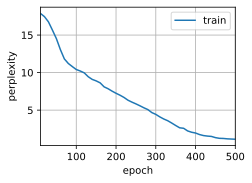

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params,
                            init_lstm_state, lstm)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

### 简洁实现

困惑度 1.1, 212735.3 词元/秒 cuda:0
time traveller for so it will be convenient to speak of himwas e
traveller his anchitt ysister all ghe thing to expect us to


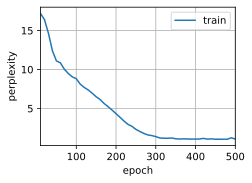

In [7]:
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 深度循环神经网络

我们可以将深度架构中的函数依赖关系形式化，这个架构是由 $L$ 个隐藏层构成。后续的讨论主要集中在经典的循环神经网络模型上，但是这些讨论也适应于其他序列模型。

假设在时间步 $t$ 有一个小批量的输入数据 $\mathbf{X}_t \in \mathbb{R}^{n \times d}$（样本数：$n$，每个样本中的输入数：$d$）。同时，将第 $l$ 个隐藏层（$l=1,\ldots,L$）的隐状态设为 $\mathbf{H}_t^{(l)} \in \mathbb{R}^{n \times h}$（隐藏单元数：$h$），输出层变量设为 $\mathbf{O}_t \in \mathbb{R}^{n \times q}$（输出数：$q$）。设置 $\mathbf{H}_t^{(0)} = \mathbf{X}_t$，第 $l$ 个隐藏层的隐状态使用激活函数 $\phi_l$，则：

$$
\mathbf{H}_t^{(l)} = \phi_l(\mathbf{H}_t^{(l-1)} \mathbf{W}_{xh}^{(l)} + \mathbf{H}_{t-1}^{(l)} \mathbf{W}_{hh}^{(l)} + \mathbf{b}_h^{(l)}),
$$

其中，权重 $\mathbf{W}_{xh}^{(l)} \in \mathbb{R}^{h \times h}$，$\mathbf{W}_{hh}^{(l)} \in \mathbb{R}^{h \times h}$ 和偏置 $\mathbf{b}_h^{(l)} \in \mathbb{R}^{1 \times h}$ 都是第 $l$ 个隐藏层的模型参数。

最后，输出层的计算仅基于第 $L$ 个隐藏层最终的隐状态：

$$
\mathbf{O}_t = \mathbf{H}_t^{(L)} \mathbf{W}_{hq} + \mathbf{b}_q,
$$

其中，权重 $\mathbf{W}_{hq} \in \mathbb{R}^{h \times q}$ 和偏置 $\mathbf{b}_q \in \mathbb{R}^{1 \times q}$ 都是输出层的模型参数。

与多层感知机一样，隐藏层数目 $L$ 和隐藏单元数目 $h$ 都是超参数。另外，用门控循环单元或长短期记忆网络的隐状态来代替 (9.3.1) 中的隐状态进行计算，可以很容易地得到深度门控循环神经网络或深度长短期记忆神经网络。

<div align="center">
    <img src="../img/深度循环神经网络结构.png">
<div>

### 简洁实现

In [8]:
import torch 
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [9]:
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
device = d2l.try_gpu()
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)

### 训练与预测

困惑度 1.0, 157359.1 词元/秒 cuda:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


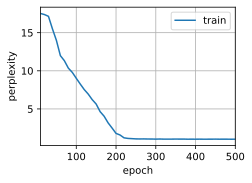

In [10]:
num_epochs, lr = 500, 2
d2l.train_ch8(model, train_iter, vocab, lr*1.0, num_epochs, device)

## 双向循环神经网络

跳了

### 隐马尔可夫模型中的动态规划

跳了

### 双向模型

相当于每次从样本中，同时由前往后和有后往前训练

$$
\begin{aligned}
\overrightarrow{\mathbf{H}}_t &= \phi(\mathbf{X}_t \mathbf{W}_{xh}^{(f)} + \overrightarrow{\mathbf{H}}_{t-1} \mathbf{W}_{hh}^{(f)} + \mathbf{b}_h^{(f)}), \\
\overleftarrow{\mathbf{H}}_t &= \phi(\mathbf{X}_t \mathbf{W}_{xh}^{(b)} + \overleftarrow{\mathbf{H}}_{t+1} \mathbf{W}_{hh}^{(b)} + \mathbf{b}_h^{(b)}),
\end{aligned}
$$

其中，权重和偏置的形状为：

- $\mathbf{W}_{xh}^{(f)} \in \mathbb{R}^{d \times h}$，$\mathbf{W}_{hh}^{(f)} \in \mathbb{R}^{h \times h}$，$\mathbf{b}_h^{(f)} \in \mathbb{R}^{1 \times h}$
- $\mathbf{W}_{xh}^{(b)} \in \mathbb{R}^{d \times h}$，$\mathbf{W}_{hh}^{(b)} \in \mathbb{R}^{h \times h}$，$\mathbf{b}_h^{(b)} \in \mathbb{R}^{1 \times h}$

我们将前向和后向隐状态连接起来，获得需要送入输出层的隐状态 $\mathbf{H}_t \in \mathbb{R}^{n \times 2h}$。在具有多个隐藏层的深度双向循环神经网络中，$\mathbf{H}_t$ 作为输入传递到下一个双向层。此外，所有的前向隐状态和后向隐状态都来自最后一层，然后它们被送入输出层。

输出层计算输出 $\mathbf{O}_t \in \mathbb{R}^{n \times q}$（$q$ 是输出个数）：

$$
\mathbf{O}_t = \mathbf{H}_t \mathbf{W}_{hq} + \mathbf{b}_q.
$$

其中，权重矩阵 $\mathbf{W}_{hq} \in \mathbb{R}^{2h \times q}$，偏置 $\mathbf{b}_q \in \mathbb{R}^{1 \times q}$。事实上，这两个方向可以使用不同数量的隐藏单元。

<div align="center">
    <img src="../img/双向模型.png">
<div>

### 双向循环神经网络的错误应用

由于双向循环神经⽹络使⽤了过去的和未来的数据，所以我们不能盲⽬地将这⼀语⾔模型应⽤于任何预测任务。尽管模型产出的困惑度是合理的，该模型预测未来词元的能⼒却可能存在严重缺陷。我们⽤下⾯的⽰例代码引以为戒，以防在错误的环境中使⽤它们。

困惑度 1.1, 84704.0 词元/秒 cuda:0
time travellerererererererererererererererererererererererererer
travellerererererererererererererererererererererererererer


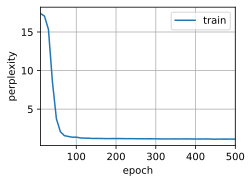

In [11]:
import torch
from torch import nn
from d2l import torch as d2l

# 加载数据
batch_size, num_steps, device = 32, 35, d2l.try_gpu()
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
# 通过设置“bidirective=True”来定义双向LSTM模型
vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens, num_layers, bidirectional=True)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
# 训练模型
num_epochs, lr = 500, 1
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 机器翻译与数据集

In [12]:
import os
import torch
from d2l import torch as d2l

### 下载和预处理数据集

In [13]:
#@save
d2l.DATA_HUB['fra-eng'] = (d2l.DATA_URL + 'fra-eng.zip',
                            '94646ad1522d915e7b0f9296181140edcf86a4f5')

#@save
def read_data_nmt():
    """载⼊“英语－法语”数据集"""
    data_dir = d2l.download_extract('fra-eng')
    with open(os.path.join(data_dir, 'fra.txt'), 'r',
                encoding='utf-8') as f:
        return f.read()

raw_text = read_data_nmt()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [14]:
#@save
def preprocess_nmt(text):
    """预处理“英语——法语” 数据集"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    
    # 使用空格替换不间断空格
    # 使用小写字母替换大写字母
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在单词和标点符号之间插入空格
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
            for i, char in enumerate(text)]
    return ''.join(out)

text = preprocess_nmt(raw_text)
print(text[:80])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça alors !


### 词元化

In [18]:
#@save
# 对前num_examples个⽂本序列对进⾏词元
def tokenize_nmt(text, num_examples=None):
    """词元化 “英语——法语” 数据数据集"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target
    
source, target = tokenize_nmt(text)
source[:6], target[:6]

([['go', '.'],
  ['hi', '.'],
  ['run', '!'],
  ['run', '!'],
  ['who', '?'],
  ['wow', '!']],
 [['va', '!'],
  ['salut', '!'],
  ['cours', '!'],
  ['courez', '!'],
  ['qui', '?'],
  ['ça', 'alors', '!']])

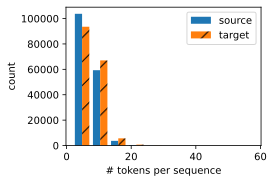

In [19]:
#@save
def show_list_len_pair_hist(legend, xlabel, ylabel, xlist, ylist):
    """绘制列表⻓度对的直⽅图"""
    d2l.set_figsize()
    _, _, patches = d2l.plt.hist(
            [[len(l) for l in xlist], [len(l) for l in ylist]])
    d2l.plt.xlabel(xlabel)
    d2l.plt.ylabel(ylabel)
    for patch in patches[1].patches:
        patch.set_hatch('/')
    d2l.plt.legend(legend)
    
show_list_len_pair_hist(['source', 'target'], '# tokens per sequence',
    'count', source, target)

### 词表

由于机器翻译数据集由语⾔对组成，因此我们可以分别为源语⾔和⽬标语⾔构建两个词表。使⽤单词级词元化时，词表⼤⼩将明显⼤于使⽤字符级词元化时的词表⼤⼩。为了缓解这⼀问题，这⾥我们将出现次数少于2次的低频率词元视为相同的未知（“<unk>”）词元。除此之外，我们还指定了额外的特定词元，例如在⼩批量时⽤于将序列填充到相同⻓度的填充词元（“<pad>”），以及序列的开始词元（“<bos>”）和结束词元（“<eos>”）。这些特殊词元在⾃然语⾔处理任务中⽐较常⽤。

In [20]:
src_vocab = d2l.Vocab(source, min_freq=2,
                        reserved_tokens=['<pad>', '<bos>', '<eos>'])
len(src_vocab)

10012

### 加载数据集

为了提⾼计算效率，我们仍然可以通过截断（truncation）和填充（padding）⽅式实现⼀次只处理⼀个⼩批量的⽂本序列。假设同⼀个⼩批量中的每个序列都应该具有相同的⻓度num_steps，那么如果⽂本序列的词元数⽬少于num_steps时，我们将继续在其末尾添加特定的“<pad>”词元，直到其⻓度达到num_steps；反之，我们将截断⽂本序列时，只取其前num_steps 个词元，并且丢弃剩余的词元。这样，每个⽂本序列将具有相同的⻓度，以便以相同形状的⼩批量进⾏加载。

In [21]:
#@save
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps] # 截断
    return line + [padding_token] * (num_steps - len(line)) # 填充

truncate_pad(src_vocab[source[0]], 10, src_vocab['<pad>'])

[47, 4, 1, 1, 1, 1, 1, 1, 1, 1]

现在我们定义⼀个函数，可以将⽂本序列转换成⼩批量数据集⽤于训练。我们将特定的“<eos>”词元添加到所有序列的末尾，⽤于表⽰序列的结束。当模型通过⼀个词元接⼀个词元地⽣成序列进⾏预测时，⽣成的“<eos>”词元说明完成了序列输出⼯作。

In [23]:
#@save
def build_array_nmt(lines, vocab, num_steps):
    """将机器翻译的文本序列转换成小批量"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(
        l, num_steps, vocab['<pad>']) for l in lines]) 
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len

### 训练模型

In [25]:
#@save
def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回翻译数据集的迭代器和词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = d2l.Vocab(source, min_freq=2,
                            reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = d2l.Vocab(target, min_freq=2,
                            reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = d2l.load_array(data_arrays, batch_size)
    return data_iter, src_vocab, tgt_vocab

In [26]:
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size=2, num_steps=8)
for X, X_valid_len, Y, Y_valid_len in train_iter:
    print('X:', X.type(torch.int32))
    print('X的有效长度:', X_valid_len)
    print('Y:', Y.type(torch.int32))
    print('Y的有效长度:', Y_valid_len)
    break

X: tensor([[83, 15,  4,  3,  1,  1,  1,  1],
        [ 6, 94,  4,  3,  1,  1,  1,  1]], dtype=torch.int32)
X的有效长度: tensor([4, 4])
Y: tensor([[0, 4, 3, 1, 1, 1, 1, 1],
        [6, 7, 0, 4, 3, 1, 1, 1]], dtype=torch.int32)
Y的有效长度: tensor([3, 5])


### 练习

某些语言（例如中文和日语）的文本没有单词边界指示符（例如空格）。对于这种情况，单词级词元化仍然是个好主意吗？为什么？

    以中文为例，中文中不存在类似空格这样的单词边界指示符，但是中文可采用基于词典、基于规则或者基于统计的分词方法，针对中文文本进行分词，以此实现中文的词元化处理。
    
    这种方法可以将中文文本划分为单独的词语，以实现对中文的精确处理。例如在词义消歧时，单词级的中文分词可以帮助我们更准确的确定词语的上下文，以此来确定歧义词的准确意义。并且在信息检索任务中，很多检索都是基于关键词展开的，对中文进行单词级词元化，可以便于在索引中进行文本匹配。因此，即便中文和日语这些语言中没有单词边界指示符，但在进行自然语言处理时，单词级的词元化仍是非常关键的一步。

## 编码器-解码器架构

机器翻译是序列转换模型的⼀个核⼼问题，其输⼊和输出都是⻓度可变的序列。为了处理这种类型的输⼊和输出，我们可以设计⼀个包含两个主要组件的架构：第⼀个组件是⼀个编码器（encoder）：它接受⼀个⻓度可变的序列作为输⼊，并将其转换为具有固定形状的编码状态。第⼆个组件是解码器（decoder）：它将固定形状的编码状态映射到⻓度可变的序列。这被称为编码器-解码器（encoder-decoder）架构。

<div align="center">
    <img src="../img/编码器-解码器架构.png">
<div>

由于“编码器－解码器”架构是形成后续章节中不同序列转换模型的基础，因此本节将把这个架构转换为接⼝⽅便后⾯的代码实现。

### 编码器

In [1]:
from torch import nn

#@save
class Encoder(nn.Module):
    """编码器-解码器架构的基本编码器接口"""
    def __init__(self, **kwargs):
        super(Encoder, self).__init__(**kwargs)

    def forward(self, X, *args):
        raise NotImplementedError

### 解码器

在下⾯的解码器接⼝中，我们新增⼀个init_state函数，⽤于将编码器的输出（enc_outputs）转换为编码后的状态。注意，此步骤可能需要额外的输⼊，例如：输⼊序列的有效⻓度，这在9.5.4节中进⾏了解释。为了逐个地⽣成⻓度可变的词元序列，解码器在每个时间步都会将输⼊（例如：在前⼀时间步⽣成的词元）和编码后的状态映射成当前时间步的输出词元。

In [2]:
#@save
class Decoder(nn.Module):
    """编码器-解码器架构的基本解码器接口"""
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)

    def init_state(self, enc_ouputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

### 合并编码器和解码器

总⽽⾔之，“编码器-解码器”架构包含了⼀个编码器和⼀个解码器，并且还拥有可选的额外的参数。在前向传播中，编码器的输出⽤于⽣成编码状态，这个状态⼜被解码器作为其输⼊的⼀部分。

In [3]:
#@save
class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)

## 序列到序列学习(seq2seq)

遵循编码器－解码器架构的设计原则，循环神经⽹络编码器使⽤⻓度可变的序列作为输⼊，将其转换为固定形状的隐状态。换⾔之，输⼊序列的信息被编码到循环神经⽹络编码器的隐状态中。为了连续⽣成输出序列的词元，独⽴的循环神经⽹络解码器是基于输⼊序列的编码信息和输出序列已经看⻅的或者⽣成的词元来预测下⼀个词元。

<div align="center">
    <img src="../img/seq2seq.png">
<div>

特定的“<eos>”表⽰序列结束词元。⼀旦输出序列⽣成此词元，模型就会停⽌预测。在循环神经⽹络解码器的初始化时间步，有两个特定的设计决定：⾸先，特定的“<bos>”表⽰序列开始词元，它是解码器的输⼊序列的第⼀个词元。其次，使⽤循环神经⽹络编码器最终的隐状态来初始化解码器的隐状态。编码器最终的隐状态在每⼀个时间步都作为解码器的输⼊序列的⼀部分。

In [4]:
import collections
import math
import torch
from torch import nn
from d2l import torch as d2l

### 编码器

从技术上讲，编码器将长度可变的输入序列转换成形状固定的上下文变量 $\mathbf{c}$，并且将输入序列的信息在该上下文变量中进行编码。如 图9.7.1 所示，可以使用循环神经网络来设计编码器。

考虑由一个序列组成的样本（批量大小是 $1$）。假设输入序列是 $x_1, \ldots, x_T$，其中 $x_t$ 是输入文本序列中的第 $t$ 个词元。在时间步 $t$，循环神经网络将词元 $x_t$ 的输入特征向量 $\mathbf{x}_t$ 和 $\mathbf{h}_{t-1}$（即上一时间步的隐状态）转换为 $\mathbf{h}_t$（即当前步的隐状态）。使用一个函数 $f$ 来描述循环神经网络的循环层所做的变换：

$$
\mathbf{h}_t = f(\mathbf{x}_t, \mathbf{h}_{t-1}).
$$

总之，编码器通过选定的函数 $q$，将所有时间步的隐状态转换为上下文变量：

$$
\mathbf{c} = q(\mathbf{h}_1, \ldots, \mathbf{h}_T).
$$

比如，当选择 $q(\mathbf{h}_1, \ldots, \mathbf{h}_T) = \mathbf{h}_T$ 时（就像 图9.7.1 中一样），上下文变量仅仅是输入序列在最后时间步的隐状态 $\mathbf{h}_T$。

到目前为止，我们使用的是一个单向循环神经网络来设计编码器，其中隐状态只依赖于输入子序列，这个子序列是由输入序列的开始位置到隐状态所在的时间步的位置（包括隐状态所在的时间步）组成。我们也可以使用双向循环神经网络构造编码器，其中隐状态依赖于两个输入子序列，两个子序列是由隐状态所在的时间步的位置之前的序列和之后的序列（包括隐状态所在的时间步），因此隐状态对整个序列的信息都进行了编码。

现在，让我们实现循环神经网络编码器。注意，我们使用了嵌入层（embedding layer）来获得输入序列中每个词元的特征向量。嵌入层的权重是一个矩阵，其行数等于输入词表的大小（vocab_size），其列数等于特征向量的维度（embed_size）。对于任意输入词元的索引 $i$，嵌入层获取权重矩阵的第 $i$ 行（从 $0$ 开始）以返回其特征向量。另外，本文选择了一个多层门控循环单元来实现编码器。

In [5]:
#@save
class Seq2SeqEncoder(d2l.Encoder):
    """用于序列到序列学习的循环神经网络编码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                dropout=0, **kwargs):
        super(Seq2SeqEncoder, self).__init__(**kwargs)
        # 嵌入层
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, 
                            dropout=dropout)

    def forward(self, X, *args):
        # 输出'X'的形状：(batch_size, num_steps, embed_size)
        X = self.embedding(X)
        # 在循环神经网络模型中，第一个轴对应于时间步
        X = X.permute(1, 0, 2)
        output, state = self.rnn(X)
        # output的形状：(num_steps, batch_size, num_hiddens)
        # state的形状: (num_layer, batch_size, num_hiddens)
        return output, state

In [6]:
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                            num_layers=2)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)
output, state = encoder(X)
output.shape

torch.Size([7, 4, 16])

In [7]:
state.shape

torch.Size([2, 4, 16])

### 解码器

在输出序列上的任意时间步 $t^\prime$，循环神经网络将来自上一时间步的输出 $y_{t^\prime-1}$ 和上下文变量 $\mathbf{c}$ 作为其输入，然后在当前时间步将它们和上一隐状态 $\mathbf{s}_{t^\prime-1}$ 转换为隐状态 $\mathbf{s}_{t^\prime}$。因此，可以使用函数 $g$ 来表示解码器的隐藏层的变换：

$$
\mathbf{s}_{t^\prime} = g(y_{t^\prime-1}, \mathbf{c}, \mathbf{s}_{t^\prime-1}).
$$

在获得解码器的隐状态之后，我们可以使用输出层和 softmax 操作来计算在时间步 $t^\prime$ 时输出 $y_{t^\prime}$ 的条件概率分布 $P(y_{t^\prime} \mid y_1, \ldots, y_{t^\prime-1}, \mathbf{c})$。

当实现解码器时，我们直接使用编码器最后一个时间步的隐状态来初始化解码器的隐状态。这就要求使用循环神经网络实现的编码器和解码器具有相同数量的层和隐藏单元。为了进一步包含经过编码的输入序列的信息，上下文变量在所有的时间步与解码器的输入进行拼接（concatenate）。为了预测输出词元的概率分布，在循环神经网络解码器的最后一层使用全连接层来变换隐状态。

In [8]:
class Seq2SeqDecoder(d2l.Decoder):
    """用于序列到序列学习的循环神经网络解码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                    dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, 
                            dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]

    def forward(self, X, state):
        # 输出'X'的形状：(batch_size, num_steps, embed_size)
        X = self.embedding(X).permute(1, 0, 2)
        # 广播context，使其具有与X相同的num_steps
        context = state[-1].repeat(X.shape[0], 1, 1)
        X_and_context = torch.cat((X, context), 2)
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output).permute(1, 0, 2)
        # output的形状：(batch_size, num_steps, vocab_size)
        # state的形状：(num_layers, num_steps, num_hideens)
        return output, state

In [9]:
decoder = Seq2SeqDecoder(vocab_size=10, embed_size=8, num_hiddens=16,
                            num_layers=2)
decoder.eval()
state = decoder.init_state(encoder(X))
output, state = decoder(X, state)
output.shape, state.shape

(torch.Size([4, 7, 10]), torch.Size([2, 4, 16]))

<div align="center">
    <img src="../img/编码器-解码器模型中的层.png">
<div>

### 损失函数

在每个时间步，解码器预测了输出词元的概率分布。类似于语⾔模型，可以使⽤softmax来获得分布，并通过计算交叉熵损失函数来进⾏优化。回想⼀下9.5节中，特定的填充词元被添加到序列的末尾，因此不同⻓度的序列可以以相同形状的⼩批量加载。但是，我们应该将填充词元的预测排除在损失函数的计算之外。
为此，我们可以使⽤下⾯的sequence_mask函数通过零值化屏蔽不相关的项，以便后⾯任何不相关预测的计算都是与零的乘积，结果都等于零。例如，如果两个序列的有效⻓度（不包括填充词元）分别为和，则第⼀个序列的第⼀项和第⼆个序列的前两项之后的剩余项将被清除为零。

In [10]:
#@save
def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不想关的项"""
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

X = torch.tensor([[1, 2, 3], [4, 5, 6]])
sequence_mask(X, torch.tensor([1, 2]))

tensor([[1, 0, 0],
        [4, 5, 0]])

In [11]:
X = torch.ones(2, 3, 4)
sequence_mask(X, torch.tensor([1, 2]), value=-1)

tensor([[[ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.],
         [-1., -1., -1., -1.]],

        [[ 1.,  1.,  1.,  1.],
         [ 1.,  1.,  1.,  1.],
         [-1., -1., -1., -1.]]])

现在，我们可以通过扩展softmax交叉熵损失函数来遮蔽不相关的预测。最初，所有预测词元的掩码都设置为1。⼀旦给定了有效⻓度，与填充词元对应的掩码将被设置为0。最后，将所有词元的损失乘以掩码，以过滤掉损失中填充词元产⽣的不相关预测。

In [12]:
#@save
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮蔽的softmax交叉熵损失函数"""
    # pred的形状：(batch_size, num_steps, vocab_size)
    # label的形状：(batch_size, num_steps)
    # valien_len的形状：(batch_size,)
    def forward(self, pred, label, valien_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valien_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

In [13]:
loss = MaskedSoftmaxCELoss()
loss(torch.ones(3, 4, 10), torch.ones((3, 4), dtype=torch.long),
        torch.tensor([4, 2, 0]))

tensor([2.3026, 1.1513, 0.0000])

### 训练

在下⾯的循环训练过程中，如图9.7.1所⽰，特定的序列开始词元（“<bos>”）和原始的输出序列（不包括序列结束词元“<eos>”）拼接在⼀起作为解码器的输⼊。这被称为强制教学（teacherforcing），因为原始的输出序列（词元的标签）被送⼊解码器。或者，将来⾃上⼀个时间步的预测得到的词元作为解码器的当前输⼊。

In [14]:
#@save
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型"""
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2) # 训练损失总和，词元数量
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                                    device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1) # 强制教学
            Y_hat, _ = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward() # 损失函数的标量进行“反向传播”
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
            f'tokens/sec on {str(device)}')


loss 0.019, 13910.1 tokens/sec on cuda:0


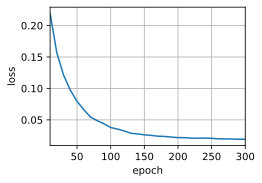

In [15]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 300, d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers,
                            dropout)
decoder = Seq2SeqDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers,
                            dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

### 预测

In [16]:
#@save
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device, save_attention_weights=False):
    """序列到序列模型的预测"""
    # 在预测时将net设置为评估模式
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
    src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = d2l.truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    # 添加批量轴
    enc_X = torch.unsqueeze(
    torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    # 添加批量轴
    dec_X = torch.unsqueeze(torch.tensor(
    [tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)
    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)
        # 我们使⽤具有预测最⾼可能性的词元，作为解码器在下⼀时间步的输⼊
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(dim=0).type(torch.int32).item()
        # 保存注意⼒权重（稍后讨论）
        if save_attention_weights:
            attention_weight_seq.append(net.decoder.attention_weights)
        # ⼀旦序列结束词元被预测，输出序列的⽣成就完成了
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

### 预测序列的评估

In [17]:
def bleu(pred_seq, label_seq, k): #@save
    """计算BLEU"""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1- len_label / len_pred))
    for n in range(1, k + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label- n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred- n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
        label_subs[' '.join(pred_tokens[i: i + n])]-= 1
        score *= math.pow(num_matches / (len_pred- n + 1), math.pow(0.5, n))
    return score

In [19]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = predict_seq2seq(
            net, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est l'ai riche partie bon qui maison l'ai qui, bleu 0.258
i'm home . => je suis chez moi ., bleu 1.000


### 练习

如果编码器和解码器的层数或者隐藏单元数不同，那么如何初始化解码器的隐状态？

如果编码器和解码器的层数或隐藏单元数不同，可以采取以下方法来初始化解码器的隐状态：

- 使用编码器隐藏状态的线性变换：如果编码器和解码器的隐藏单元数不同，可以通过线性变换将编码器隐藏状态的维度调整为解码器隐藏状态所需的维度。可以使用全连接层或线性映射来实现这个变换。
- 使用零向量进行初始化：如果编码器和解码器的隐藏单元数差异较大，或者无法进行有效的维度变换，可以使用零向量来初始化解码器的隐状态。这种方法可能会导致一开始解码器的性能较差，但随着训练的进行，解码器可以逐渐学习到适应目标任务的隐状态表示。

## 束搜索

跳了，总之贪心搜索并不符合最好的数学模型，但是穷举搜索耗费时间过长，所以束搜索可以平衡精确性和计算量。